In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Kan vi importere tidymodels data som R fil, ikke CSV?

!pip install pyreadr

import pyreadr

model_data = pyreadr.read_r("model_data_clean.rds")[None]

print(model_data.info())

# ── FEATURES ────────────────────────────────────────────────────────────────

target_col = "churn"

quant_cols = [
    "account_active_days",
    "previous_subscriptions",
    "previous_campaigns",
    "previous_trials",
    "newsletters_before_order",
    "newsletters_after_order",
    "age"
]

cat_cols = [
    "koen",
    "permission_given_order",
    "permission_given_today",
    "kundetid_gruppe",
    "cluster_label"
]

# ── TARGET ──────────────────────────────────────────────────────────────────
y = model_data[target_col].astype(int).values

# ── FEATURES ────────────────────────────────────────────────────────────────
X_cat_dummies = pd.get_dummies(model_data[cat_cols], drop_first=False)

X_df = pd.concat(
    [model_data[quant_cols].reset_index(drop=True),
     X_cat_dummies.reset_index(drop=True)],
    axis=1
)

# ── TRAIN/TEST SPLIT ────────────────────────────────────────────────────────
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.20, random_state=8, stratify=y
)

# ── SCALING ─────────────────────────────────────────────────────────────────
scaler = StandardScaler()

X_train_arr = X_train_df.copy()
X_test_arr = X_test_df.copy()

X_train_arr[quant_cols] = scaler.fit_transform(X_train_df[quant_cols])
X_test_arr[quant_cols] = scaler.transform(X_test_df[quant_cols])

# ── FINAL ARRAYS ────────────────────────────────────────────────────────────
X_train = X_train_arr.values.astype(np.float32)
X_test = X_test_arr.values.astype(np.float32)

# ── CHECK ───────────────────────────────────────────────────────────────────
print(X_train.shape)
print("Churn rate:", y_train.mean())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.3/788.3 kB 11.0 MB/s eta 0:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   account_active_days       1259 non-null   int32   
 1   koen                      1259 non-null   category
 2   permission_given_order    1259 non-null   category
 3   permission_given_today    1259 non-null   category
 4   previous_subscriptions    1259 non-null   int32   
 5   previous_campaigns        1259 non-null   int32   
 6   previous_trials           1259 non-null   int32   
 7   newsletters_before_order  1259 non-null   int32   
 8   newsletters_after_order   1259 non-null   int32   
 9   churn                     1259 non-null   category
 10  early_churn               1259 non-null   float64 
 11  age                       1259 non-null   float64 
 12  kundetid_gruppe        

In [ ]:
# model_01
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K, callbacks, regularizers

K.clear_session()
tf.random.set_seed(8)

# ── 2. BUILD MODEL 01 ────────────────────────────────────────────────────────
# X_train.shape[1] automatically knows how many features you have from before
model_01 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
], name="baseline_nn")

model_01.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# ── 3. TRAINING ──────────────────────────────────────────────────────────────
# Using y_train and X_train directly from your previous script execution
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Model 01 (Baseline)...")
history_01 = model_01.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

# ── 4. EVALUATE ──────────────────────────────────────────────────────────────
# Using X_test and y_test from your previous script execution
metrics_01 = model_01.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*30)
print(f"Model 01 TEST AUC: {metrics_01[2]:.4f}")
print(f"Model 01 TEST ACC: {metrics_01[1]:.4f}")
print("="*30)

Training Model 01 (Baseline)...
Epoch 1/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5503 - auc: 0.5373 - loss: 0.7681 - val_accuracy: 0.6089 - val_auc: 0.5646 - val_loss: 0.7533
Epoch 2/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5888 - auc: 0.6187 - loss: 0.7380 - val_accuracy: 0.6040 - val_auc: 0.5946 - val_loss: 0.7457
Epoch 3/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5975 - auc: 0.6199 - loss: 0.7296 - val_accuracy: 0.5941 - val_auc: 0.6186 - val_loss: 0.7370
Epoch 4/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6149 - auc: 0.6677 - loss: 0.7119 - val_accuracy: 0.6139 - val_auc: 0.6352 - val_loss: 0.7304
Epoch 5/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6273 - auc: 0.6809 - loss: 0.6971 - val_accuracy: 0.6337 - val_auc: 0.6635 - val_loss: 0.7154
Epoch 6/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6435 - auc: 0.6938 - loss: 0.6878 - val_accuracy: 0.6436 - val_auc: 0.6726 - val_loss: 0.7130
Epoch 7/

In [ ]:
# model_02
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K, callbacks, regularizers

K.clear_session()
tf.random.set_seed(8)

# ── 2. BUILD THE DEEP MODEL (Complex Architecture) ───────────────────────────
model_02 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    # Layer 1: Wide initial layer + BatchNormalization
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.002)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Layer 2: Medium layer
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.002)),
    layers.Dropout(0.3),

    # Layer 3: Final refinement
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    # Output layer
    layers.Dense(1, activation="sigmoid")
], name="complex_nn_model")

# Using a custom learning rate as per your Model 02 setup
model_02.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Recall(name="recall")]
)

# ── 3. ADVANCED CALLBACKS ────────────────────────────────────────────────────
# These help the model navigate complex loss landscapes
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

# ── 4. TRAIN ─────────────────────────────────────────────────────────────────
print("Training Model 02 (Complex NN)...")
history_02 = model_02.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ── 5. EVALUATE ──────────────────────────────────────────────────────────────
metrics_02 = model_02.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*40)
print(f"Model 02 TEST AUC:      {metrics_02[2]:.4f}")
print(f"Model 02 TEST RECALL:   {metrics_02[3]:.4f}")
print(f"Model 02 TEST ACC:      {metrics_02[1]:.4f}")
print("="*40)

Training Model 02 (Complex NN)...
Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.5391 - auc: 0.4796 - loss: 1.0565 - recall: 0.3050 - val_accuracy: 0.5495 - val_auc: 0.5256 - val_loss: 0.9290 - val_recall: 0.2716 - learning_rate: 0.0010
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6000 - auc: 0.6031 - loss: 0.9396 - recall: 0.4633 - val_accuracy: 0.6089 - val_auc: 0.5907 - val_loss: 0.9174 - val_recall: 0.2469 - learning_rate: 0.0010
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5963 - auc: 0.6170 - loss: 0.9189 - recall: 0.3754 - val_accuracy: 0.6337 - val_auc: 0.6425 - val_loss: 0.9086 - val_recall: 0.3951 - learning_rate: 0.0010
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6348 - auc: 0.6444 - loss: 0.8977 - recall: 0.4809 - val_accuracy: 0.6535 - val_auc: 0.6570 - val_loss: 0.8980 - val_recall: 0.4815 - learning_rate: 0.0010
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6435 - auc: 

In [ ]:
# model_03
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers, backend as K

K.clear_session()
tf.random.set_seed(8)

# ── 2. APPLY SMOTE (Balancing the Training Set) ──────────────────────────────
# We use X_train and y_train that were already prepped and scaled
# in your cleaning script.
sm = SMOTE(random_state=8)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original shape: {X_train.shape}")
print(f"Resampled shape (SMOTE): {X_train_res.shape}")

# ── 3. BUILD MODEL 03 (Architecture matching your R-style setup) ──────────────
model_03 = tf.keras.Sequential([
    layers.Input(shape=(X_train_res.shape[1],)),

    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(1, activation="sigmoid")
], name="nn_smote_balanced")

model_03.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# ── 4. TRAINING ──────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

print("Training Model 03 (SMOTE Balanced)...")
history_03 = model_03.fit(
    X_train_res, y_train_res,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test), # Validate on the original, un-SMOTEd test data
    callbacks=[early_stop],
    verbose=1
)

# ── 5. EVALUATION ────────────────────────────────────────────────────────────
results_03 = model_03.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*35)
print(f"MODEL 03 TEST AUC:      {results_03[2]:.4f}")
print(f"MODEL 03 TEST ACCURACY: {results_03[1]:.4f}")
print("="*35)

Original shape: (1007, 23)
Resampled shape (SMOTE): (1170, 23)
Training Model 03 (SMOTE Balanced)...
Epoch 1/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5026 - auc: 0.5000 - loss: 0.7258 - val_accuracy: 0.5833 - val_auc: 0.6018 - val_loss: 0.7107
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5556 - auc: 0.5645 - loss: 0.7132 - val_accuracy: 0.5794 - val_auc: 0.6397 - val_loss: 0.7045
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5880 - auc: 0.6245 - loss: 0.6986 - val_accuracy: 0.5992 - val_auc: 0.6621 - val_loss: 0.6967
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5983 - auc: 0.6282 - loss: 0.6950 - val_accuracy: 0.5952 - val_auc: 0.6748 - val_loss: 0.6888
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6128 - auc: 0.6558 - loss: 0.6825 - val_accuracy: 0.6230 - val_auc: 0.6881 - val_loss: 0.6810
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6427 - auc: 0.6903 - loss: 0.6688

In [ ]:
# model_04
from imblearn.over_sampling import SMOTENC
import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers, backend as K

K.clear_session()
tf.random.set_seed(8)

# ── 1. IDENTIFY CATEGORICAL FEATURE INDICES ────────────────────────────────
# These are the one-hot encoded columns
categorical_cols = X_cat_dummies.columns.tolist()
cat_idx = [X_train_df.columns.get_loc(col) for col in categorical_cols]

# ── 2. APPLY SMOTENC (Correct handling of mixed data) ───────────────────────
sm = SMOTENC(
    categorical_features=cat_idx,
    random_state=8,
    k_neighbors=5
)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original shape: {X_train.shape}")
print(f"Resampled shape (SMOTENC): {X_train_res.shape}")

# ── 3. MODEL ARCHITECTURE ───────────────────────────────────────────────────
model_04 = tf.keras.Sequential([
    layers.Input(shape=(X_train_res.shape[1],)),

    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(1, activation="sigmoid")
], name="nn_smotenc_balanced")

model_04.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# ── 4. TRAINING ─────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

print("Training Model 04 (SMOTENC Balanced)...")
history_04 = model_04.fit(
    X_train_res, y_train_res,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),  # untouched test set
    callbacks=[early_stop],
    verbose=1
)

# ── 5. EVALUATION ───────────────────────────────────────────────────────────
results_04 = model_04.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*35)
print(f"MODEL 04 TEST AUC:      {results_04[2]:.4f}")
print(f"MODEL 04 TEST ACCURACY: {results_04[1]:.4f}")
print("="*35)

Original shape: (1007, 23)
Resampled shape (SMOTENC): (1170, 23)
Training Model 04 (SMOTENC Balanced)...
Epoch 1/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5368 - auc: 0.5553 - loss: 0.7171 - val_accuracy: 0.5714 - val_auc: 0.5845 - val_loss: 0.7088
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5444 - auc: 0.5824 - loss: 0.7067 - val_accuracy: 0.5913 - val_auc: 0.6177 - val_loss: 0.7041
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5803 - auc: 0.6238 - loss: 0.6961 - val_accuracy: 0.5913 - val_auc: 0.6462 - val_loss: 0.6971
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6120 - auc: 0.6448 - loss: 0.6858 - val_accuracy: 0.6230 - val_auc: 0.6717 - val_loss: 0.6906
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6154 - auc: 0.6622 - loss: 0.6756 - val_accuracy: 0.6389 - val_auc: 0.6832 - val_loss: 0.6842
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6402 - auc: 0.6825 - loss: 0.6751 

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


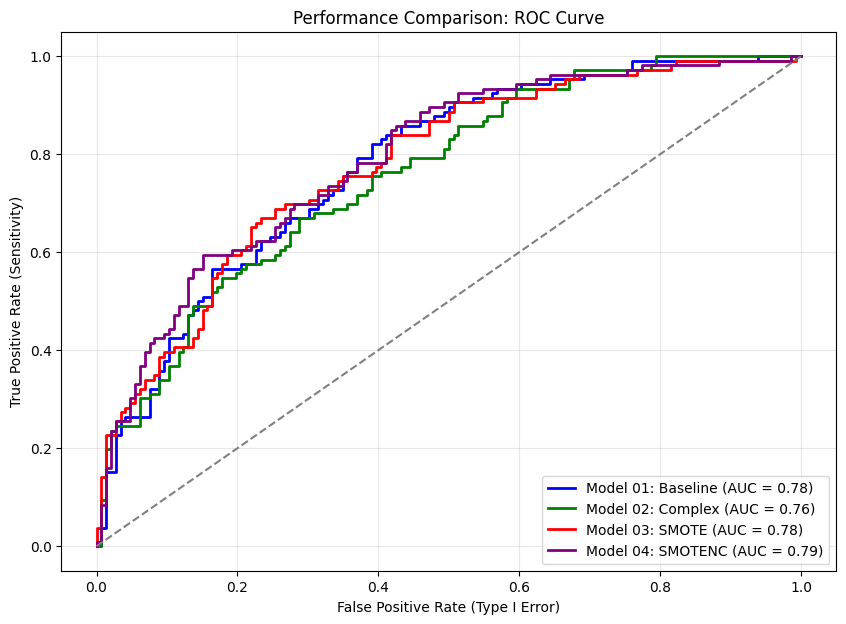

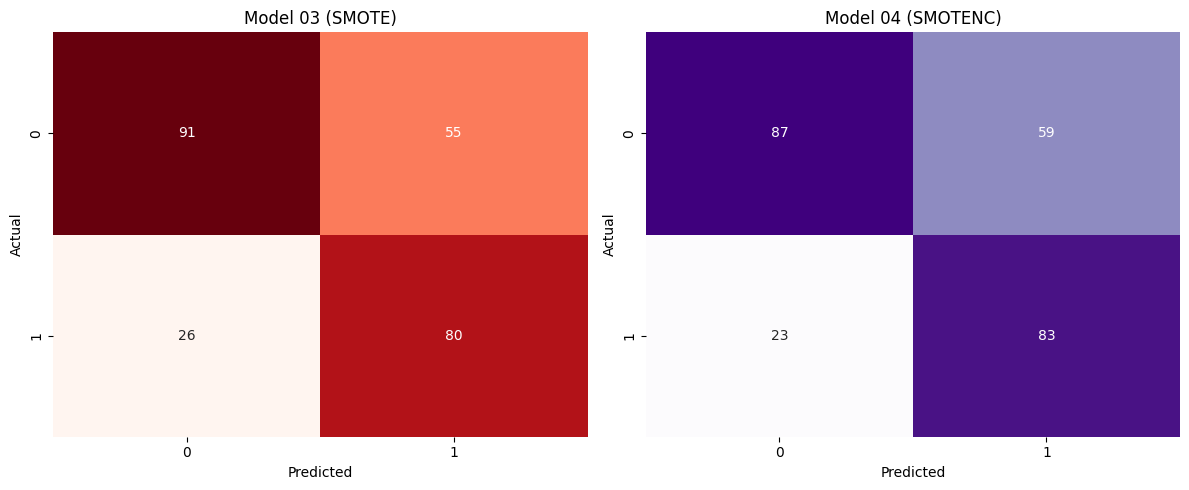


--- Model Performance Leaderboard ---
              Model   AUC  Recall (Churn Caught)  Accuracy
 Model 04 (SMOTENC) 0.792                  0.783     0.675
Model 01 (Baseline) 0.779                  0.689     0.694
   Model 03 (SMOTE) 0.779                  0.755     0.679
 Model 02 (Complex) 0.759                  0.613     0.679


In [ ]:
# ── VISUALISATION: MODEL COMPARISON ──────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc, recall_score, accuracy_score

# 1. GENERATE PREDICTIONS
# All models use the same X_test (important: SMOTE/SMOTENC only affects training data)

probs_01 = model_01.predict(X_test)
probs_02 = model_02.predict(X_test)
probs_03 = model_03.predict(X_test)
probs_04 = model_04.predict(X_test)

# Convert probabilities to class predictions (0.5 threshold)
preds_03 = (probs_03 > 0.5).astype(int)
preds_04 = (probs_04 > 0.5).astype(int)

# 2. CREATE A 4-WAY ROC COMPARISON
plt.figure(figsize=(10, 7))

model_data = [
    (probs_01, 'Model 01: Baseline', 'blue'),
    (probs_02, 'Model 02: Complex', 'green'),
    (probs_03, 'Model 03: SMOTE', 'red'),
    (probs_04, 'Model 04: SMOTENC', 'purple')
]

for probs, label, color in model_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (Type I Error)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Performance Comparison: ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 3. CONFUSION MATRICES (Model 03 + Model 04)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_03 = confusion_matrix(y_test, preds_03)
sns.heatmap(cm_03, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[0])
axes[0].set_title('Model 03 (SMOTE)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_04 = confusion_matrix(y_test, preds_04)
sns.heatmap(cm_04, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[1])
axes[1].set_title('Model 04 (SMOTENC)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 4. LEADERBOARD TABLE
results = []

for m_name, m_probs in [
    ("Model 01 (Baseline)", probs_01),
    ("Model 02 (Complex)",  probs_02),
    ("Model 03 (SMOTE)",    probs_03),
    ("Model 04 (SMOTENC)",  probs_04)
]:
    m_preds = (m_probs > 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_test, m_probs)

    results.append({
        "Model": m_name,
        "AUC": round(auc(fpr, tpr), 3),
        "Recall (Churn Caught)": round(recall_score(y_test, m_preds), 3),
        "Accuracy": round(accuracy_score(y_test, m_preds), 3)
    })

print("\n--- Model Performance Leaderboard ---")
print(pd.DataFrame(results).sort_values(by="AUC", ascending=False).to_string(index=False))

In [22]:
import numpy as np
import pandas as pd

# Best case scenario

# 1. Her defineres inputdata for et "best case" scenarie
test_data = {
    "Aktive dage": 1000,
    "Tidligere subscriptions": 1,
    "tidligere kampagner": 1,
    "Tidligere trials": 0,
    "nyhedsbreve_før_ordre": 1,
    "nyhedsbreve_efter_ordre": 1,
    "Alder": 60,
    "Gender": "Mand",
    "Klynge": "Veteranen (Høj historik)",
    "Kundetid": "6+ måneder"
}

# 2. De numeriske variabler skaleres, så de matcher modelens træning
# (forudsætter at scaler allerede er trænet og tilgængelig i sessionen)
numeric_input = np.array([[
    test_data["Aktive dage"],
    test_data["Tidligere subscriptions"],
    test_data["tidligere kampagner"],
    test_data["Tidligere trials"],
    test_data["nyhedsbreve_før_ordre"],
    test_data["nyhedsbreve_efter_ordre"],
    test_data["Alder"]
]])
scaled_numeric = scaler.transform(numeric_input)

# 3. Der oprettes en tom feature-matrix med samme struktur som modellen forventer
# Her er alle værdier sat til 0 som udgangspunkt
X_verify = np.zeros((1, 23))
X_verify[0, 0:7] = scaled_numeric

# 4. De kategoriske variabler indsættes manuelt, så de matcher encoding-strukturen
# (skal stemme overens med den mapping der er brugt i Power BI / træning)

# Køn
if test_data["Gender"] == "Mand":
    X_verify[0, 7] = 1
elif test_data["Gender"] == "Kvinde":
    X_verify[0, 8] = 1

# Klynge
if test_data["Klynge"] == "Veteranen (Høj historik)":
    X_verify[0, 14] = 1

# Kundetid
if test_data["Kundetid"] == "6+ måneder":
    X_verify[0, 19] = 1

# 5. Til sidst laves en forudsigelse med den trænede model
colab_prediction = model_04.predict(X_verify)
print(f"NN Prediction af best case: {colab_prediction[0][0] * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
NN Prediction af best case: 2.72%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
import numpy as np
import pandas as pd

# Worst case scenario

# 1. Her opstilles et "worst case" scenarie, hvor kunden har lav aktivitet og lav historik
test_data_high_risk = {
    "Aktive dage": 10,
    "Tidligere subscriptions": 0,
    "tidligere kampagner": 0,
    "Tidligere trials": 0,
    "nyhedsbreve_før_ordre": 0,
    "nyhedsbreve_efter_ordre": 0,
    "Alder": 25,
    "Gender": "Mand",
    "Klynge": "Mobil-nykommeren",
    "Kundetid": "0-7 dage"
}

# 2. De numeriske værdier skaleres, så de passer til modellens inputformat
numeric_input = np.array([[
    test_data_high_risk["Aktive dage"],
    test_data_high_risk["Tidligere subscriptions"],
    test_data_high_risk["tidligere kampagner"],
    test_data_high_risk["Tidligere trials"],
    test_data_high_risk["nyhedsbreve_før_ordre"],
    test_data_high_risk["nyhedsbreve_efter_ordre"],
    test_data_high_risk["Alder"]
]])
scaled_numeric = scaler.transform(numeric_input)

# 3. Der oprettes en tom feature-vektor med samme struktur som modellen forventer
# Alle værdier initialiseres til 0, hvorefter relevante features sættes manuelt
X_verify = np.zeros((1, 23))
X_verify[0, 0:7] = scaled_numeric

# 4. De kategoriske variable indkodes manuelt, så de matcher encoding-strukturen fra Power BI

# Køn
if test_data_high_risk["Gender"] == "Mand":
    X_verify[0, 7] = 1
elif test_data_high_risk["Gender"] == "Kvinde":
    X_verify[0, 8] = 1

# Klynge: Mobil-nykommeren er placeret på index 10 i den anvendte mapping
X_verify[0, 10] = 1

# Kundetid: 0-7 dage er placeret på index 16 i mappingen
X_verify[0, 16] = 1

# 5. Til sidst foretages en forudsigelse med den trænede model
colab_pred = model_04.predict(X_verify, verbose=0)
print(f"NN Prediction af worst case: {colab_pred[0][0] * 100:.2f}%")

NN Prediction af worst case: 80.23%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
